# **Implementation of R-CNN for Object Detection**
Done by:
- Siddharth Sudhakar (MTech AI - 25901335)

In [1]:
!pip install torch torchvision
!pip install opencv-python
!pip install selectivesearch
!pip install scikit-learn
!pip install tqdm

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4336 sha256=e667ec8005d34e501c3418d29d699a81f7779fd1b0c2fa1a44953f2cbc9c93a1
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch


In [2]:
!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
!unzip PennFudanPed.zip

--2026-03-02 06:01:24--  https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
Resolving www.cis.upenn.edu (www.cis.upenn.edu)... 158.130.69.163, 2607:f470:8:64:5ea5::d
Connecting to www.cis.upenn.edu (www.cis.upenn.edu)|158.130.69.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53723336 (51M) [application/zip]
Saving to: ‘PennFudanPed.zip’

PennFudanPed.zip    100%[===================>]  51.23M  10.9MB/s    in 5.6s    

2026-03-02 06:01:31 (9.11 MB/s) - ‘PennFudanPed.zip’ saved [53723336/53723336]

Archive:  PennFudanPed.zip
   creating: PennFudanPed/
  inflating: PennFudanPed/added-object-list.txt  
   creating: PennFudanPed/Annotation/
  inflating: PennFudanPed/Annotation/FudanPed00001.txt  
  inflating: PennFudanPed/Annotation/FudanPed00002.txt  
  inflating: PennFudanPed/Annotation/FudanPed00003.txt  
  inflating: PennFudanPed/Annotation/FudanPed00004.txt  
  inflating: PennFudanPed/Annotation/FudanPed00005.txt  
  inflating: PennFudanPed/Annotati

In [37]:
import os
import time
import numpy as np
import cv2
import torch
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import selectivesearch
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.svm import LinearSVC

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "PennFudanPed"

In [38]:
def load_image(idx):
    img_path = os.path.join(DATA_DIR, "PNGImages", f"FudanPed{idx:05d}.png")
    mask_path = os.path.join(DATA_DIR, "PedMasks", f"FudanPed{idx:05d}_mask.png")

    img = Image.open(img_path).convert("RGB")
    mask = np.array(Image.open(mask_path))

    obj_ids = np.unique(mask)[1:]

    boxes = []
    for obj_id in obj_ids:
        pos = np.where(mask == obj_id)
        xmin = np.min(pos[1])
        xmax = np.max(pos[1])
        ymin = np.min(pos[0])
        ymax = np.max(pos[0])
        boxes.append([xmin, ymin, xmax, ymax])

    return np.array(img), boxes

In [39]:
train_ids = list(range(1, 41))
test_ids  = list(range(41, 61))

# Selective Search

In [40]:
def generate_proposals(img):
    _, regions = selectivesearch.selective_search(
        img, scale=500, sigma=0.9, min_size=10
    )

    proposals = []
    for r in regions:
        if r['size'] < 1000:
            continue
        x,y,w,h = r['rect']
        proposals.append([x,y,x+w,y+h])

    return proposals[:2000]

## Visualize Top 50

In [5]:
def visualize(img, proposals, n=20):
    fig, ax = plt.subplots(1, figsize=(8,8))
    ax.imshow(img)

    for box in proposals[:n]:
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                             fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)

    plt.show()

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


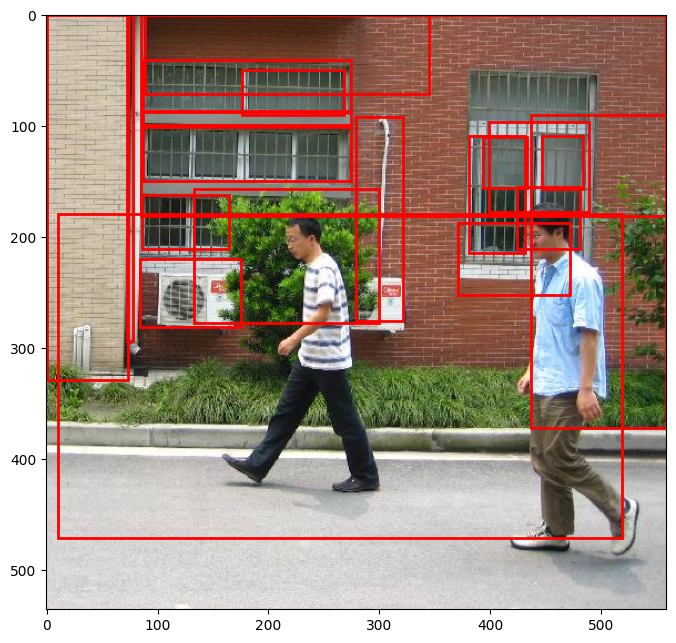

In [6]:
img, gt_boxes = load_image(1)
props = generate_proposals(img)
visualize(img, props)

# Feature Extraction (ResNet 50)

In [41]:
resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)
resnet.eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],
                [0.229,0.224,0.225])
])

def extract_features(img, proposals):
    features = []
    valid_boxes = []

    for box in proposals:
        x1,y1,x2,y2 = box
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        crop = transform(crop).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = resnet(crop).flatten()

        features.append(feat.cpu().numpy())
        valid_boxes.append(box)

    return np.array(features), valid_boxes

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Label Using IoU

In [42]:
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter = max(0,xB-xA)*max(0,yB-yA)

    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])

    return inter/(area1+area2-inter+1e-6)

Label:

In [43]:
def label_proposals(proposals, gt_boxes):
    labels = []
    for prop in proposals:
        max_iou = max([compute_iou(prop, gt) for gt in gt_boxes])
        if max_iou > 0.5:
            labels.append(1)
        elif max_iou < 0.3:
            labels.append(0)
        else:
            labels.append(-1)
    return np.array(labels)

## Train Regression

In [44]:
X_train = []
y_train = []

for idx in tqdm(train_ids):
    img, gt_boxes = load_image(idx)
    props = generate_proposals(img)
    X, boxes = extract_features(img, props)
    y = label_proposals(boxes, gt_boxes)

    mask = y != -1
    X_train.extend(X[mask])
    y_train.extend(y[mask])

X_train = np.array(X_train)
y_train = np.array(y_train)

svm = LinearSVC(max_iter=5000)
svm.fit(X_train, y_train)

  0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 40/40 [02:57<00:00,  4.43s/it]


LinearSVC(max_iter=5000)

In [45]:
def compute_regression_targets(prop, gt):
    px1,py1,px2,py2 = prop
    gx1,gy1,gx2,gy2 = gt

    pw = px2-px1
    ph = py2-py1
    gw = gx2-gx1
    gh = gy2-gy1

    tx = (gx1-px1)/pw
    ty = (gy1-py1)/ph
    tw = np.log(gw/pw+1e-6)
    th = np.log(gh/ph+1e-6)

    return [tx,ty,tw,th]

In [46]:
reg_features = []
reg_targets = []

for idx in tqdm(train_ids):
    img, gt_boxes = load_image(idx)
    props = generate_proposals(img)
    X, boxes = extract_features(img, props)
    y = label_proposals(boxes, gt_boxes)

    for i,(prop,label) in enumerate(zip(boxes,y)):
        if label==1:
            best_gt = max(gt_boxes,key=lambda g:compute_iou(prop,g))
            reg_features.append(X[i])
            reg_targets.append(compute_regression_targets(prop,best_gt))

reg_features = np.vstack(reg_features)
reg_targets = np.vstack(reg_targets)

X_reg = torch.from_numpy(reg_features).float().to(device)
y_reg = torch.from_numpy(reg_targets).float().to(device)

regressor = torch.nn.Linear(2048,4).to(device)
optimizer = torch.optim.Adam(regressor.parameters(),lr=1e-3)
loss_fn = torch.nn.SmoothL1Loss()

for epoch in range(20):
    optimizer.zero_grad()
    preds = regressor(X_reg)
    loss = loss_fn(preds,y_reg)
    loss.backward()
    optimizer.step()

  0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 40/40 [02:57<00:00,  4.43s/it]


# Non-Max Suppression

In [47]:
def nms(boxes,scores,threshold=0.5):
    idxs=np.argsort(scores)[::-1]
    keep=[]
    while len(idxs)>0:
        current=idxs[0]
        keep.append(current)
        idxs=idxs[1:]
        idxs=[i for i in idxs if compute_iou(boxes[current],boxes[i])<threshold]
    return keep

## Evaluation (AP)

In [48]:
def evaluate_model(use_regression=False):
    total_tp=[]
    total_fp=[]
    total_iou=[]
    total_time=0

    for idx in tqdm(test_ids):
        img,gt_boxes=load_image(idx)

        start=time.time()
        props=generate_proposals(img)
        X,boxes=extract_features(img,props)
        scores=svm.decision_function(X)

        pred_indices=np.where(scores>0)[0]
        pred_boxes=[boxes[i] for i in pred_indices]
        pred_scores=scores[pred_indices]

        if use_regression:
            deltas=regressor(torch.from_numpy(X[pred_indices]).float().to(device))
            deltas=deltas.detach().cpu().numpy()
            new_boxes=[]
            for box,delta in zip(pred_boxes,deltas):
                new_boxes.append(apply_regression(box,delta))
            pred_boxes=new_boxes

        keep=nms(pred_boxes,pred_scores,0.5)
        pred_boxes=[pred_boxes[i] for i in keep]
        pred_scores=pred_scores[keep]

        total_time+=time.time()-start

        matched=set()
        for pb in pred_boxes:
            best_iou=0
            best_gt=-1
            for i,gt in enumerate(gt_boxes):
                if i in matched:continue
                iou=compute_iou(pb,gt)
                if iou>best_iou:
                    best_iou=iou
                    best_gt=i
            if best_iou>=0.5:
                total_tp.append(1)
                total_fp.append(0)
                matched.add(best_gt)
                total_iou.append(best_iou)
            else:
                total_tp.append(0)
                total_fp.append(1)

    tp_cum=np.cumsum(total_tp)
    fp_cum=np.cumsum(total_fp)
    precision=tp_cum/(tp_cum+fp_cum+1e-6)
    recall=tp_cum/len(total_tp)

    ap=np.trapz(precision,recall)

    return ap,np.mean(total_iou),total_time/len(test_ids)

In [49]:
ap_no_reg,iou_no_reg,time_no_reg=evaluate_model(False)
ap_reg,iou_reg,time_reg=evaluate_model(True)

  5%|▌         | 1/20 [00:05<01:42,  5.41s/it]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
 10%|█         | 2/20 [00:13<02:02,  6.82s/it]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
 15%|█▌        | 3/20 [00:19<01:52,  6.59s/it]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between

## Compare with Faster R-CNN

In [50]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn

faster=fasterrcnn_resnet50_fpn(pretrained=True).to(device)
faster.eval()

def evaluate_faster():
    total_iou=[]
    total_time=0

    for idx in tqdm(test_ids):
        img,gt_boxes=load_image(idx)
        img_tensor=T.ToTensor()(img).to(device)

        start=time.time()
        with torch.no_grad():
            preds=faster([img_tensor])
        total_time+=time.time()-start

        boxes=preds[0]['boxes'].cpu().numpy()
        scores=preds[0]['scores'].cpu().numpy()

        keep=scores>0.5
        boxes=boxes[keep]

        for pb in boxes:
            total_iou.append(max([compute_iou(pb,gt) for gt in gt_boxes]))

    return np.mean(total_iou),total_time/len(test_ids)

iou_faster,time_faster=evaluate_faster()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20/20 [00:02<00:00,  8.35it/s]


In [51]:
results=pd.DataFrame({
    "Model":[
        "R-CNN (No Regression)",
        "R-CNN (With Regression)",
        "Faster R-CNN"
    ],
    "AP":[
        round(ap_no_reg,3),
        round(ap_reg,3),
        "Pretrained"
    ],
    "Mean IoU":[
        round(iou_no_reg,3),
        round(iou_reg,3),
        round(iou_faster,3)
    ],
    "Time per Image (sec)":[
        round(time_no_reg,3),
        round(time_reg,3),
        round(time_faster,3)
    ]
})

results

,Model,AP,Mean IoU,Time per Image (sec)
0,R-CNN (No Regression),0.121,0.603,6.447
1,R-CNN (With Regression),0.099,0.604,6.274
2,Faster R-CNN,Pretrained,0.225,0.097
